In [1]:
# Importing the python libraries
import pandas as pd  # for Data preprocessing
import matplotlib.pyplot as plt  # for Data Visualization
import seaborn as sns  # for Data Visualization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,precision_score,recall_score,f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (  classification_report,confusion_matrix, roc_auc_score)


 # Load the dataset

In [2]:
# Load the engineered dataset for modelling
modelling_data = pd.read_csv(
    r'C:\Users\oyebi\Fraudulent-Transaction-Detection\Dataset\artifacts\Engineered_data.csv'
)

In [3]:
modelling_data.head()  # Display the first few rows of the dataset

,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,new_device,ip_country,...,hour,day_of_week,is_weekend,late_night_hours,amount_high,high_ip_risk,low_device_trust,new_account,very_new_account,velocity_spike
0,2022-10-03 18:40:59.468549+00:00,us,USD,CAD,atm,278.19,278.19,4.25,False,us,...,18,0,0,0,0,0,0,0,0,0
1,2022-10-03 20:39:38.468549+00:00,ca,CAD,MXN,web,208.51,154.29,4.24,True,ca,...,20,0,0,0,0,0,1,0,0,0
2,2022-10-03 23:02:43.468549+00:00,us,USD,CNY,mobile,160.33,160.33,2.70,False,us,...,23,0,0,0,0,0,0,0,0,0
3,2022-10-04 01:08:53.468549+00:00,us,USD,EUR,mobile,59.41,59.41,2.22,False,us,...,1,1,0,0,0,0,0,0,0,0
4,2022-10-04 09:35:03.468549+00:00,us,USD,INR,mobile,200.96,200.96,3.61,False,us,...,9,1,0,0,0,0,0,0,0,0


In [4]:
# Convert the timestamp column to datetime format
modelling_data['timestamp'] = pd.to_datetime(modelling_data['timestamp'])

In [5]:
# Check the data type of the timestamp column
modelling_data['timestamp'].dtype

datetime64[ns, UTC]

In [6]:
# Identifying categorical features in the modelling dataset
categorical_features = modelling_data.select_dtypes(
    include=['object', 'bool']
).columns

categorical_features

Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'new_device', 'ip_country', 'location_mismatch', 'kyc_tier'],
      dtype='object')

In [7]:
# Defining numerical features for the modelling data
numerical_features = (
    modelling_data
    .select_dtypes(include=['int', 'float'])
    .columns
    .drop('is_fraud')
)

numerical_features

Index(['amount_src', 'amount_usd', 'fee', 'ip_risk_score', 'account_age_days',
       'device_trust_score', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'hour', 'day_of_week',
       'is_weekend', 'late_night_hours', 'amount_high', 'high_ip_risk',
       'low_device_trust', 'new_account', 'very_new_account',
       'velocity_spike'],
      dtype='object')

In [8]:
# All the features in the dataset
all_features = categorical_features.tolist() + numerical_features.tolist() # predictor features
print( all_features)


['home_country', 'source_currency', 'dest_currency', 'channel', 'new_device', 'ip_country', 'location_mismatch', 'kyc_tier', 'amount_src', 'amount_usd', 'fee', 'ip_risk_score', 'account_age_days', 'device_trust_score', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'hour', 'day_of_week', 'is_weekend', 'late_night_hours', 'amount_high', 'high_ip_risk', 'low_device_trust', 'new_account', 'very_new_account', 'velocity_spike']


In [9]:
print(f"Total number of features: {len(all_features)}")

Total number of features: 28


In [10]:
# check which dataset columns are not included in all_features:
excluded_columns = modelling_data.columns.difference(all_features) # because timestamp is datetime and is_fraud is your target variable.

excluded_columns

Index(['is_fraud', 'timestamp'], dtype='object')

# separate the predictor features (X) from the target (y)

### Train-Test Split

The dataset was split into **80% training data and 20% testing data**. The training set is used to train the machine-learning models, while the testing set is reserved for evaluating model performance on unseen data.

Because the dataset contains a `timestamp` variable, the transactions were sorted chronologically before performing the train-test split. A chronological split better reflects a real-world fraud detection scenario, where a model is trained on **historical transactions and subsequently used to predict fraud in future transactions**.

Maintaining chronological order also helps reduce the risk of **temporal data leakage**. This is particularly important when working with time-dependent and behavioural features such as `txn_velocity_1h`, `txn_velocity_24h`, `new_device`, `account_age_days`, and `new_account`.

The **earliest 80% of transactions** were therefore used for model training, while the **most recent 20% of transactions** were reserved for testing.


In [11]:
# Sort the dataset chronologically
modelling_data = (
    modelling_data
    .sort_values(by='timestamp')
    .reset_index(drop=True)
)

# Determine the 80/20 split point
split_index = int(len(modelling_data) * 0.8) # this determines where to split the dataset into training and testing sets based on the 80/20 ratio.

# Use the earliest 80% of transactions for training
train_modelling_data = modelling_data.iloc[:split_index]

# Use the most recent 20% of transactions for testing
test_modelling_data = modelling_data.iloc[split_index:]

# Prepare X and y for the training set
X_train = train_modelling_data[all_features]
y_train = train_modelling_data['is_fraud']

# Prepare X and y for the testing set
X_test = test_modelling_data[all_features]
y_test = test_modelling_data['is_fraud']



X_train = predictor features from the earlier 80% of transactions
y_train = is_fraud labels for those transactions
X_test = predictor features from the later 20%
y_test = is_fraud labels for those transactions

Because  modelling_data  was sorted by timestamp, this is a time-based split, not a random split.

In [12]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (8624, 28)
y_train shape: (8624,)
X_test shape: (2156, 28)
y_test shape: (2156,)


80% training: 8,624 transactions
20% testing: 2,156 transactions
Predictor features: 28
Target: is_fraud

In [13]:
# Check fraud distribution in the training and testing sets

print("Training set:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nTesting set:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Training set:
is_fraud
0    7951
1     673
Name: count, dtype: int64
is_fraud
0    0.921962
1    0.078038
Name: proportion, dtype: float64

Testing set:
is_fraud
0    1848
1     308
Name: count, dtype: int64
is_fraud
0    0.857143
1    0.142857
Name: proportion, dtype: float64


### Fraud Distribution After the Train-Test Split

The chronological train-test split resulted in different fraud distributions between the training and testing periods.

- **Training set:** 7,951 non-fraudulent transactions and 673 fraudulent transactions, corresponding to a fraud rate of approximately **7.80%**.
- **Testing set:** 1,848 non-fraudulent transactions and 308 fraudulent transactions, corresponding to a fraud rate of approximately **14.29%**.

The higher fraud rate in the testing set indicates that fraudulent transactions are more prevalent in the later period of the dataset. This difference is expected to be possible with a chronological split because the class distribution is not artificially balanced or stratified between the training and testing sets.

The result also highlights the importance of evaluating the fraud detection models using metrics such as **precision, recall, F1-score, PR-AUC, ROC-AUC, and the confusion matrix**, rather than relying on accuracy alone.

### Data Preprocessing

ColumnTransformer is a scikit-learn tool that allows applying  different preprocessing methods to different groups of columns in the same dataset.

In this fraud dataset, this is useful because there are different types of predictors. The categorical features need encoding, while the numerical features may need scaling. ColumnTransformer helps to define both operations in one preprocessing step.

In [14]:
# Building a preprocessing pipeline for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

#### fit the preprocessor on X_train and transform both X_train and X_test.

In [15]:
1. # Fit and transform the training data

# Fit the preprocessor on the training data and transform X_train
X_train_processed = preprocessor.fit_transform(X_train)

In [16]:
# 2. Transform the test data

# Transform the testing data using the preprocessing learned from X_train
X_test_processed = preprocessor.transform(X_test)

In [17]:
#  3. Check the new shapes

print(f"Original features: {len(all_features)}")
print(f"Processed features: {X_train_processed.shape[1]}")

Original features: 28
Processed features: 42


# Training Logistic Regression with a balanced class weight

Without class weighting, Logistic Regression may focus too heavily on correctly predicting the majority non-fraud class.

class_weight='balanced': automatically gives more weight to the minority fraud class and less weight to the majority class during model training.

In [18]:
# create Logistic Regression model
lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

## Build the complete preprocessing and modelling pipeline
pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', lr_model)
    ]
) # Here, preprocessor performs your one-hot encoding and numerical scaling, while lr_model performs the Logistic Regression classification.


# Train the pipeline
pipeline.fit(X_train, y_train)


# Make Predictions
y_pred_lr = pipeline.predict(X_test)
y_prob_lr = pipeline.predict_proba(X_test)[:, 1]


# Evaluate the model
print("Logistic Regression Results:")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")



Logistic Regression Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.96      0.98      1848
       Fraud       0.80      0.95      0.87       308

    accuracy                           0.96      2156
   macro avg       0.89      0.95      0.92      2156
weighted avg       0.96      0.96      0.96      2156


Confusion Matrix:
[[1774   74]
 [  16  292]]

ROC AUC Score: 0.9835


the pipeline ensures that exactly the same preprocessing learned from the training data is automatically applied to the test data, reducing the chance of data leakage or inconsistent preprocessing.

### Logistic Regression Model Evaluation

The Logistic Regression model demonstrated strong performance in distinguishing fraudulent from genuine transactions. The model achieved an overall accuracy of approximately **96%** and an ROC-AUC score of **0.9835**, indicating excellent discriminatory ability between the two transaction classes.

For the fraud class, the model achieved a **precision of 0.80, recall of 0.95, and F1-score of 0.87**. The high recall is particularly important in the context of fraud detection, as it indicates that the model successfully identified approximately 95% of the fraudulent transactions in the test dataset.

The confusion matrix showed that **292 of the 308 fraudulent transactions were correctly detected**, while only **16 fraudulent transactions were incorrectly classified as genuine**. The model also correctly classified **1,774 genuine transactions**, although **74 genuine transactions were incorrectly flagged as fraudulent**.

Overall, the results indicate that the balanced Logistic Regression model provides strong fraud-detection performance, with particularly high sensitivity to fraudulent transactions. However, its performance should be compared with alternative classification models, and potential sources of data leakage should be assessed before selecting the final model.


Confusion MAtrix for Linear Regression

<Figure size 800x600 with 0 Axes>

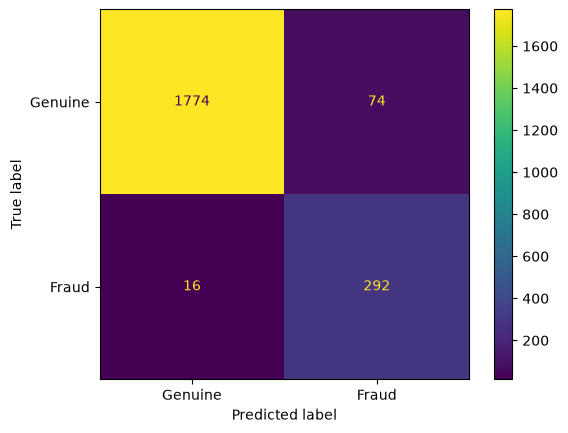

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr), display_labels=['Genuine', 'Fraud'])
plt.figure(figsize=(8, 6))
cm.plot()

## Training  Random Forest with  Balanced Class Weight

In [20]:
from sklearn.ensemble import RandomForestClassifier

# create Random Forest model
rf_model= RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=100,
    max_depth=10,
    n_jobs=-1
)


# Build the complete preprocessing and modelling pipeline
pipeline_rf = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', rf_model)
    ]
) # Here, preprocessor performs your one-hot encoding and numerical scaling, while rf_model performs the Random Forest classification.



# Train the pipeline(using raw data X_train, not processed)
pipeline_rf.fit(X_train, y_train)



# Make Predictions
y_pred_rf  = pipeline_rf.predict(X_test)
y_prob_rf  = pipeline_rf.predict_proba(X_test)[:, 1]


# Evaluate the model
print("Random Forest Results:") 
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")


Random Forest Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      1.00      0.99      1848
       Fraud       0.97      0.92      0.94       308

    accuracy                           0.98      2156
   macro avg       0.98      0.96      0.97      2156
weighted avg       0.98      0.98      0.98      2156


Confusion Matrix:
[[1839    9]
 [  25  283]]

ROC AUC Score: 0.9768


# Confusion matrix for random Forest

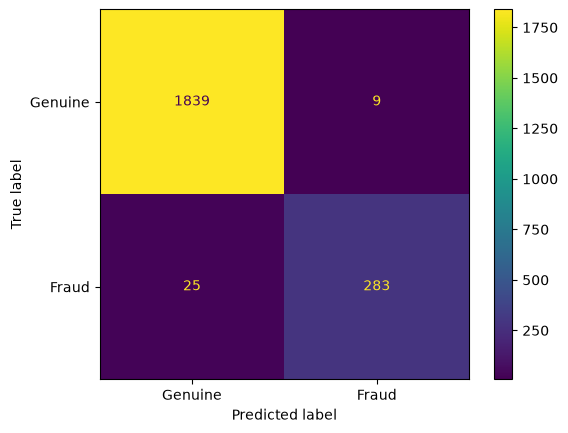

In [21]:
# Confusion matrix display

from sklearn.metrics import ConfusionMatrixDisplay

cm_rf = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf), display_labels=['Genuine', 'Fraud'])
cm_rf.plot()

Random Forest Model Evaluation

The Random Forest classifier demonstrated strong performance on the chronological test dataset. The model achieved an overall accuracy of approximately 98% and an ROC-AUC score of 0.9768, indicating excellent discriminatory ability between genuine and fraudulent transactions.

For the fraud class, the model achieved a precision of 0.97, recall of 0.92, and F1-score of 0.94. The high precision indicates that the majority of transactions classified as fraudulent were genuinely fraudulent, while the recall shows that approximately 92% of all fraudulent transactions were successfully detected.

The confusion matrix showed that the model correctly identified 1,839 genuine transactions and 283 fraudulent transactions. Only 9 genuine transactions were incorrectly flagged as fraudulent, while 25 fraudulent transactions were incorrectly classified as genuine.

Compared with Logistic Regression, Random Forest substantially reduced false-positive alerts and achieved higher fraud precision and F1-score. However, Logistic Regression detected a greater number of fraudulent transactions and produced fewer false negatives. Logistic Regression also achieved a slightly higher ROC-AUC score of 0.9835, compared with 0.9768 for Random Forest.

##  xgboost

In [22]:
from xgboost import XGBClassifier

# calculate scale pos weight for imbalance in xgboost classifier
scale_pos_weight = (y_train ==0).sum() / (y_train ==1).sum()


# create XGBoost model
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss'
)

# Build the complete preprocessing and modelling pipeline
pipeline_xgb = Pipeline(    
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', xgb_model)
    ]
) 


# Train the pipeline(using raw data X_train, not processed)
pipeline_xgb.fit(X_train, y_train)      


# Make Predictions
y_pred_xgb  = pipeline_xgb.predict(X_test)
y_prob_xgb  = pipeline_xgb.predict_proba(X_test)[:, 1]

# Evaluate the model
print("XGBoost Results:")       
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Genuine', 'Fraud']))
print("\nConfusion Matrix:")                                        
print(confusion_matrix(y_test, y_pred_xgb))
print(f"\nROC AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")


XGBoost Results:

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.99      0.99      0.99      1848
       Fraud       0.93      0.92      0.93       308

    accuracy                           0.98      2156
   macro avg       0.96      0.95      0.96      2156
weighted avg       0.98      0.98      0.98      2156


Confusion Matrix:
[[1828   20]
 [  25  283]]

ROC AUC Score: 0.9692


## Confusion matrix for Xgbooost

<Figure size 800x600 with 0 Axes>

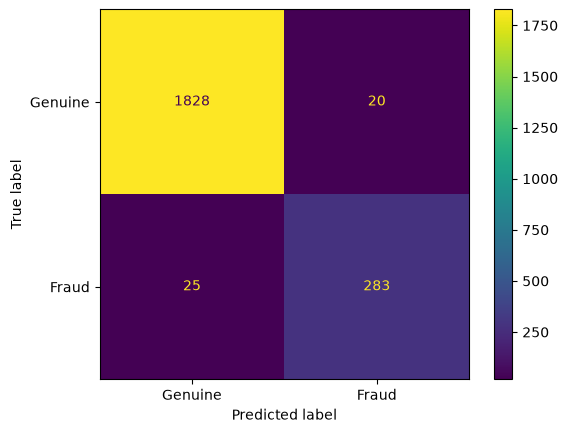

<Figure size 800x600 with 0 Axes>

In [23]:
# Confusion matrix display

from sklearn.metrics import ConfusionMatrixDisplay

cm_xgb = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb), display_labels=['Genuine', 'Fraud'])
cm_xgb.plot()
plt.figure(figsize=(8, 6))

XGBoost Model Evaluation

The XGBoost classifier demonstrated strong performance on the chronological test dataset, achieving an overall accuracy of approximately 98% and an ROC-AUC score of 0.9675.

For the fraud class, the model achieved a precision of 0.94, recall of 0.92, and F1-score of 0.93. These results indicate that the model maintained a strong balance between correctly identifying fraudulent transactions and limiting false-positive fraud alerts.

The confusion matrix showed that XGBoost correctly classified 1,829 genuine transactions and 283 fraudulent transactions. A total of 19 genuine transactions were incorrectly classified as fraudulent, while 25 fraudulent transactions were incorrectly classified as genuine.

Compared with the other baseline models, XGBoost produced substantially fewer false-positive alerts than Logistic Regression but more than Random Forest. Its fraud recall was similar to Random Forest, while Logistic Regression detected a greater proportion of the fraudulent transactions. XGBoost also achieved an ROC-AUC of 0.9675, compared with 0.9768 for Random Forest and 0.9835 for Logistic Regression.

Overall, XGBoost demonstrated strong fraud-classification performance. 

SHAP ANALYSIS

SHAP is a technique used to explain machine learning predictions, especially those made by complex models such as tree-based ensembles. It shows how each feature contributes to a model's prediction.

SHAP answers an important question:

“Why did the model classify this transaction as fraudulent?”

It does this by assigning each feature a SHAP value, which represents its positive or negative contribution to the model's prediction.

SHAP is used to interpret model predictions by quantifying the contribution of each feature to fraud risk. This improves transparency in model decision-making, helps identify key fraud drivers such as transaction velocity and IP risk score, and provides actionable insights for fraud analysts and business stakeholders.

SHAP is based on game theory, specifically Shapley values. It fairly distributes the contribution, or “credit,” for a prediction among the features used by the model.


In [24]:
import shap
import xgboost

print("shap version:", shap.__version__)
print("xgboost version:", xgboost.__version__)

c:\Users\oyebi\Fraudulent-Transaction-Detection\finlora_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


shap version: 0.52.0
xgboost version: 2.1.4


In [25]:
import shap
import pandas as pd  # for Data preprocessing
import matplotlib.pyplot as plt  # for Data Visualization


# get the preprocessor from the pipeline and transform raw X_test
X_test_preprocessed = pipeline_xgb.named_steps['preprocessor'].transform(X_test)


# Get the  XGBoost model from the pipeline
xgb_model = pipeline_xgb.named_steps['classifier']


# Get booster and calculate SHAP values
booster = xgb_model.get_booster()
explainer = shap.TreeExplainer(booster)
shap_values_gb = explainer.shap_values(X_test_preprocessed)

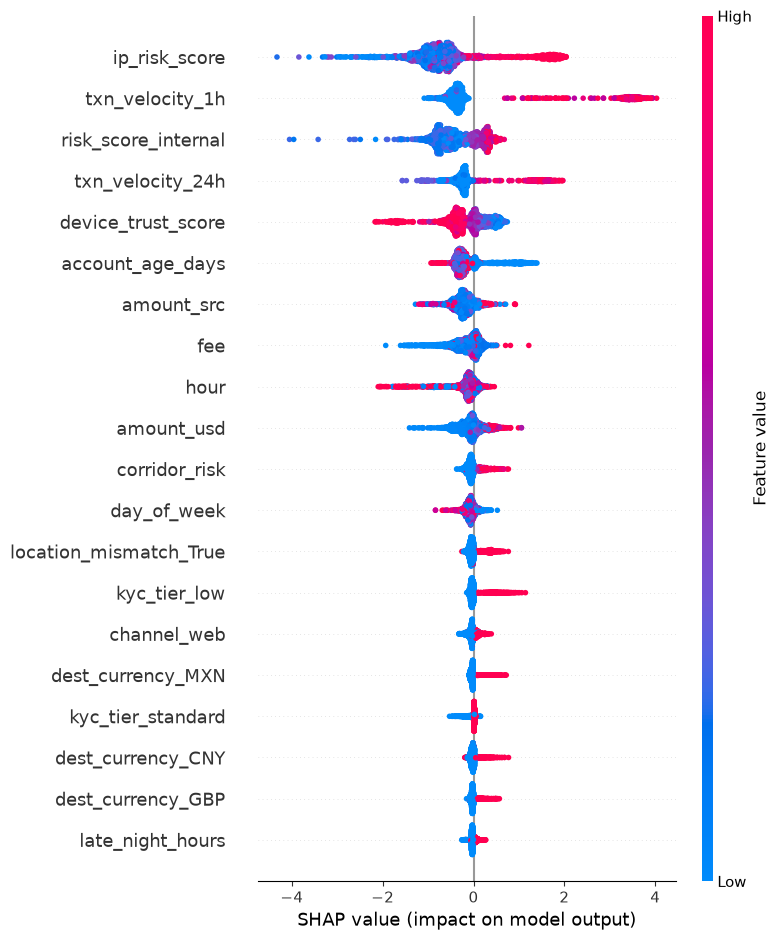

In [26]:
# Creating a clean feature name for the SHAP plot
feature_names = pipeline_xgb.named_steps['preprocessor'].get_feature_names_out()
clean_names = [name.replace("num__","").replace("cat__","")for name in feature_names]

X_test_processed_df =pd.DataFrame(
    X_test_processed,
    columns= clean_names   
)


#Beeswarm plot
shap.summary_plot(shap_values_gb, X_test_processed_df)
plt.show()


This is a SHAP beeswarm plot, and it shows which features matter most and how they influence fraud predictions. The Y-axis shows the features (ranked by importance) while the X-axis shows the SHAP value (impact on prediction). The Blue color represents Low feature value while the red color represents High feature value.

The Left part of the plot (negative SHAP value) pushes prediction toward Genuine while the Right part (positive SHAP value) pushes prediction toward Fraud.

The SHAP beeswarm plot highlights that transaction velocity spikes, location mismatch, internal risk scores, and IP risk scores are the most influential drivers of fraud predictions. High values of these features consistently push predictions toward fraud, while low values indicate genuine behaviour. The model captures a combination of behavioural anomalies, identity inconsistencies, and account risk factors, aligning closely with real-world fraud detection patterns.



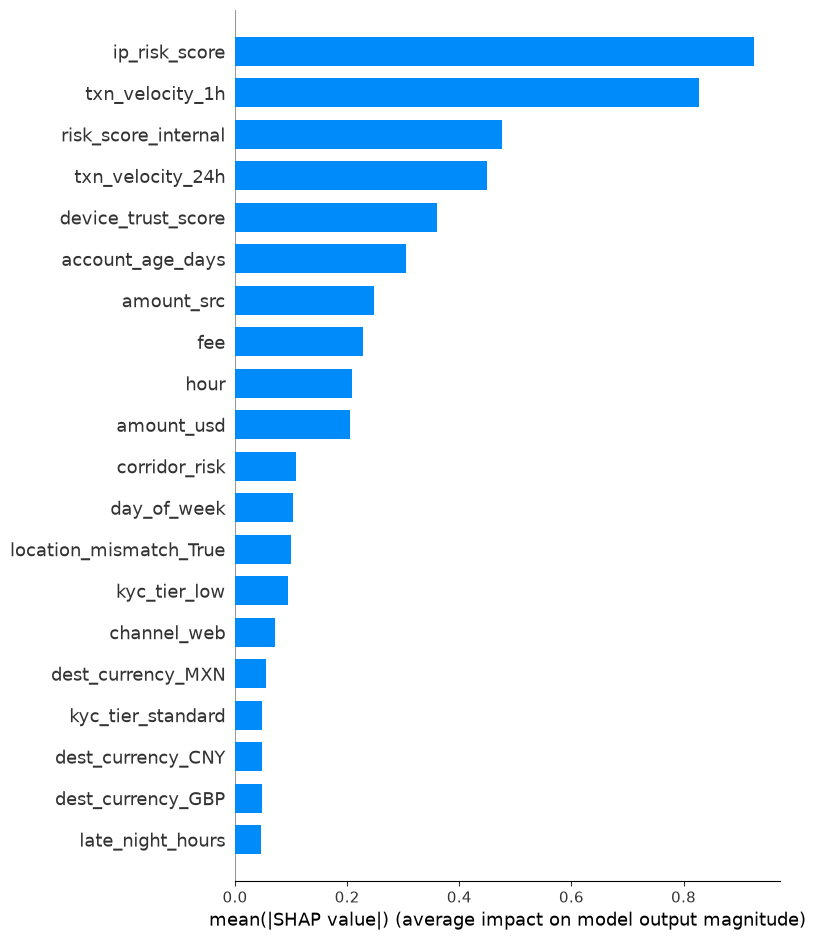

In [27]:
# Summary bar plot
shap.summary_plot(shap_values_gb,X_test_processed_df, plot_type= 'bar')

## Model registering

In [28]:
import dagshub
import mlflow
import mlflow.sklearn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


# Initialize Dagshub
import dagshub
dagshub.init(repo_owner='oyebim', 
             repo_name='Fraudulent-Transaction-Detection', 
             mlflow=True)


Accessing as oyebim

Initialized MLflow to track repo "oyebim/Fraudulent-Transaction-Detection"

Repository oyebim/Fraudulent-Transaction-Detection initialized!

What does set_experiment() mean?

Think of an MLflow experiment as a folder where you keep all related model trials.

You are telling MLflow:

“Put all the model runs for my FinLora fraud-detection project inside an experiment called Fraudulent-Transaction-Detection_Models_For Finlora.”

Inside that experiment, you can have separate runs:
Fraudulent-Transaction-Detection_Models_For Finlora
│
├── Logistic Regression
│   ├── Accuracy
│   ├── Precision
│   ├── Recall
│   ├── F1-score
│   └── ROC-AUC
│
├── Random Forest
│   ├── Accuracy
│   ├── Precision
│   ├── Recall
│   ├── F1-score
│   └── ROC-AUC
│
└── XGBoost
    ├── Accuracy
    ├── Precision
    ├── Recall
    ├── F1-score
    └── ROC-AUC

In [29]:
# Set Experiment
mlflow.set_experiment('Fraudulent-Transaction-Detection_Models_For Finlora')


# Start MLflow run and register model
with mlflow.start_run() as run:
    # Log model parameters
    mlflow.log_params(xgb_model.get_params())


    # Make predictions using the pipeline
    y_pred = pipeline_xgb.predict(X_test)
    y_pred_proba = pipeline_xgb.predict_proba(X_test)[:, 1]


    # Log metrics
    mlflow.log_metrics({
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred),
        'recall' : recall_score(y_test, y_pred),
        'f1_score' : f1_score(y_test, y_pred),
        'auc_roc' : roc_auc_score(y_test, y_pred_proba)})


    # Log the entire pipeline (preprocessor + model) with cloudpickle serialization
    mlflow.sklearn.log_model(
        pipeline_xgb,
        "xgboost_fraud_detection_pipeline",
        registered_model_name="Fraud_Detection_XGBoost_Pipeline",
        serialization_format="cloudpickle"
    )

    print("Model registered successfully")
    print(f"Run ID: {run.info.run_id}")



2026/09/29 20:02:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/29 20:03:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'Fraud_Detection_XGBoost_Pipeline' already exists. Creating a new version of this model...
2026/09/29 20:04:49 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Fraud_Detection_XGBoost_Pipeline, version 9
Created version '9' of model 'Fraud_Detection_XGBoost_Pipeline'.


Model registered successfully
Run ID: d8332afe3eda428582f68217fdfeff41
🏃 View run valuable-hen-284 at: https://dagshub.com/oyebim/Fraudulent-Transaction-Detection.mlflow/#/experiments/0/runs/d8332afe3eda428582f68217fdfeff41
🧪 View experiment at: https://dagshub.com/oyebim/Fraudulent-Transaction-Detection.mlflow/#/experiments/0
